# Tarea 1 — Extracción y traducción de proteínas desde ADN

Este notebook implementa funciones para identificar y traducir genes en una
secuencia de ADN. A partir de una URL, se descarga la secuencia, se detectan
los marcos de lectura delimitados por codones de inicio (`ATG`)
y stop (`TAA`, `TAG`, `TGA`), y se traducen a secuencias de aminoácidos usando
la tabla de codones de ADN.

Cada proteína traducida se representa como una instancia de la clase `Protein`.

---


## 1. `Protein` *(NamedTuple)*
Representa una proteína traducida a partir de una región del ADN.

#### Estructura del Objeto
```python
Protein(start: int, stop: int, length: int, sequence: str)
```


#### Atributos
| key      | Tipo  | Descripción                                        |
|------------|-------|--------------------------------------------------|
| `start`    | `int` | Índice de inicio del gen en la secuencia de ADN  |
| `stop`     | `int` | Índice de término del gen en la secuencia de ADN |
| `length`   | `int` | Número de aminoácidos en la secuencia traducida  |
| `sequence` | `str` | Secuencia de aminoácidos en formato de una letra |

<br> 

---
<br> 

## 2. Funciones principales

### 2.1 `get_proteins(dna, sort, show)`

Función que orquesta el resto de las funciones: extrae, filtra, ordena y traduce los genes de una secuencia de ADN. **retorna**: `tuple[list[Protein], int]` — Tupla con la lista de `Proteins` traducidas y el total de genes encontrados antes del filtro del parámetro `show`.

```python
def get_proteins(
    dna: str,             
    sort: str = "desc_len",
    show: int | None = 3
) -> tuple[list[Protein], int]
```

**Parámetros**

| Nombre         | Tipo           | Descripción                                                                 |
|----------------|----------------|-----------------------------------------------------------------------------|
| `dna`          | `str`          | Secuencia de ADN a analizar                                                 |
| `sort`         | `str`          | Criterio de ordenamiento (mismo que `sort_genes`, default: `"desc_len"`)    |
| `show`         | `int` o `None` | Máximo de proteínas a retornar; `None` retorna todas (default: `3`)           |

<br> 

**Valores válidos para `sort`**

| Valor        | Descripción                                |
|--------------|--------------------------------------------|
| `"desc_len"` | Más largos primero                         |
| `"asc_len"`  | Más cortos primero                         |
| `"asc_pos"`  | Primeros en la secuencia                   |
| `"desc_pos"` | Últimos en la secuencia                    |

<br> 


### 2.2 `protein_finder(dna)`

Retorna una función que, dado un índice de inicio, busca y traduce la proteína que comienza en esa posición de la secuencia de ADN.

```python
def protein_finder(dna: str) -> Callable[[int], Protein]
```

**Retorna**  
`Callable[[int], Protein]` — Función `find(start)` que recibe un índice de inicio y retorna el objeto `Protein` correspondiente.

<br>

**Ejemplo**
```python
finder = protein_finder(dna)
protein = finder(461)   # Proteína que inicia en la posición 461
```

<br>

---

<br>

In [ ]:
from typing import NamedTuple
import requests
import re
import sys
import matplotlib.pyplot as plt

class Protein(NamedTuple):
    start: int
    stop: int
    length: int
    sequence: str


CODON_TAB = {
    "GTT": "V", "GTC": "V", "GTA": "V", "GTG": "V", "GCT": "A", "GCC": "A", "GCA": "A", "GCG": "A",
    "GAT": "D", "GAC": "D", "GAA": "E", "GAG": "E", "GGT": "G", "GGC": "G", "GGA": "G", "GGG": "G",
    "AGA": "R", "AGG": "R", "AGT": "S", "AGC": "S", "AAT": "N", "AAC": "N", "AAA": "K", "AAG": "K",
    "ACT": "T", "ACC": "T", "ACA": "T", "ACG": "T", "ATT": "I", "ATC": "I", "ATA": "I", "ATG": "M",
    "CGT": "R", "CGC": "R", "CGA": "R", "CGG": "R", "CCT": "P", "CCC": "P", "CCA": "P", "CCG": "P",
    "CAT": "H", "CAC": "H", "CAA": "Q", "CAG": "Q", "TTT": "F", "TTC": "F", "TTA": "L", "TTG": "L",
    "TCT": "S", "TCC": "S", "TCA": "S", "TCG": "S", "TAT": "Y", "TAC": "Y", "TAA": "*", "TAG": "*",
    "TGT": "C", "TGC": "C", "TGA": "*", "TGG": "W", "CTT": "L", "CTC": "L", "CTA": "L", "CTG": "L"
}


URL = "https://raw.githubusercontent.com/Anscharius-anq/PILE/refs/heads/main/tarea_1.txt"

# constante usada como parametros por defecto en las funciones
MIN_RESIDUES = 30 # longitud mínima de un gen que se considerará para mostrar su proteína traducida

def url_content(url: str) -> str:
    """
    Obtiene el contenido de una URL.

    Args:
        url (str): La URL de la que obtener el contenido.

    Returns:
        str: El contenido de la URL.
    """
    # se hace la solicitud HTTP y se maneja cualquier error que pueda ocurrir
    try:
        response = requests.get(url)
        response.raise_for_status()
        return response.text
    except requests.exceptions.HTTPError as e:
        raise RuntimeError(
            f"Error HTTP {e.response.status_code}: {url}"
        ) from e
    except requests.exceptions.RequestException as e:
        raise RuntimeError(
            f"No se pudo conectar con el servidor: {url}"
        ) from e


def get_dna(text: str) -> str:
    '''
    Extrae y devuelve la secuencia de ADN del texto dado en el argumento `text`. 
    Si no se encuentra una secuencia de ADN válida, se lanza un error.
    '''
    dna_lines = []
    # se corta el texto en líneas a una lista y se procesa cada línea
    for line in text.splitlines():
        clean = re.sub(r"\s", "", line).upper() # se eliminan espacios y se convierten a mayúsculas
        if clean and re.fullmatch(r"[ATCG]+", clean): # se extraen secuencias ATCG dentro de la línea
            dna_lines.append(clean)

    if not dna_lines:
        raise ValueError("No se encontró una secuencia de ADN válida en el texto.")

    return "".join(dna_lines)


def dna_indices(dna: str, /, min_residues: int = MIN_RESIDUES) -> list[tuple[int, int]]:
    '''
    Devuelve una lista de tuplas `[(start, stop), ...]` con los indices de inicio (ATG) y termino
    (TAA, TAG o TGA) de cada gen encontrado en la secuencia de ADN dada en el parametro `dna`.

    El parametro `min_residues` se utiliza para filtrar genes que tengan una longitud menor a ese número
    de residuos. 

    '''
    
    pattern = r"(?=(ATG(?:[ACGT]{3})*?T(?:GA|AA|AG)))"
    matches = re.finditer(pattern, dna) 
    seen_stops = set() # evita genes solapados con el mismo codón de termino
    genes = [] # lista de tuplas con indices de inicio y termino de cada gen encontrado

    for m in matches:
        start, stop = m.span(1) 
        if stop in seen_stops: 
            continue

        length_aa = ((stop - start) // 3 ) - 1
        if length_aa >= min_residues:
            seen_stops.add(stop) # marca el codon de termino como ocupado
            genes.append((start, stop))

    return genes


def sort_genes(genes: list[tuple[int, int]], /, sort: str = "desc_len", show: int = 3) -> list[tuple[int, int]]:
    '''
    Ordena y filtra una lista de genes según el criterio indicado en `sort`,
    retornando como máximo `show` tuplas `(start, stop)`.
    '''
    
    match sort:
        case "asc_len": # ordena por longitud de gen de menor a mayor
            key, reverse = lambda x: x[1] - x[0], False
        case "desc_len": # ordena por longitud de gen de mayor a menor
            key, reverse = lambda x: x[1] - x[0], True
        case "asc_pos": # ordena por posición de inicio de gen de menor a mayor
            key, reverse = lambda x: x[0], False
        case "desc_pos": # ordena por posición de inicio de gen de mayor a menor
            key, reverse = lambda x: x[0], True
        case _:
            raise ValueError(f"Valor de ordenamiento no válido: {sort}")
        
    return sorted(genes, key=key, reverse=reverse)[:show]


def translation(dna: str, gene_regions: list[tuple[int, int]]) -> list[Protein]:
    '''
    Traduce una lista de regiones `(start, stop)` a objetos `Protein`,
    usando la tabla de codones `CODON_TAB`.
    '''

    proteins = []

    for start, stop in gene_regions:
        protein_seq = []
        for j in range(start, stop, 3):
            codon = dna[j : j + 3]
            amino_acid = CODON_TAB.get(codon, "?")

            if amino_acid == "*":
                break

            protein_seq.append(amino_acid)

        proteins.append(
            Protein(
                start=start,
                stop=stop,
                length=len(protein_seq),
                sequence="".join(protein_seq),
            )
        )
    return proteins


def protein_finder(dna: str):
    genes = dna_indices(dna)  
    def find(start: int) -> Protein:
        match = next((g for g in genes if g[0] == start), None)
        if match is None:
            raise ValueError(f"No se encontró proteína en posición {start}")
        return translation(dna, [match])[0]
    return find

# orquesta todas las funciones anteriores para obtener las proteinas. 
def get_proteins(dna: str, sort: str = "desc_len", show: int | None = 3):
    genes = dna_indices(dna)
    top = sort_genes(genes, sort=sort, show=show if show is not None else len(genes))
    return translation(dna, top), len(genes)

def main():
    try:
        dna = get_dna(url_content(URL))
    except (RuntimeError, ValueError) as e:
        print(f"ERROR: {e}")
        sys.exit(1)

    proteins, total = get_proteins(dna, sort="asc_pos")

    print(f"Se muestran {len(proteins)} de {total} proteínas encontradas\n")

    for _, p in enumerate(proteins, start=1):
        print(f"[posicion: {p.start}]: {p.length} aa\n{p.sequence}\n")

if __name__ == "__main__":
    main()

Se muestran 3 de 8 proteínas encontradas

[posicion: 461]: 155 aa
MAQALPWLLLWMGAGVLPAHGTQHGIRLPLRSGLGGAPLGLRLPRETDEEPEEPGRRGSFVEMVDNLRGKSGQGYYVEMTVGSPPQTVRWSGQPLALRLHEQRGDRMGMPQASPCSNGLVGTAGGTPPQPFPGGHVVVGRSVPKLPIPSSSPLAA

[posicion: 759]: 82 aa
MSRGETGWGCLKLAPAQMGWWGQQEGPLPSHSPGVTWLLAEVFPSSPFPPRLPWLPSSPCSSSDTYAVWKDLRQDRHISWGP

[posicion: 1405]: 35 aa
MVGKEPELPFKSGTPSMAGERGVTEKTLLCPPHPS



### Todas las proteínas encontradas en la secuencia de ADN

Se obtiene la secuencia de ADN desde la URL y se llama a `get_proteins` con `show=None`
para obtener  **todas** las proteínas sin filtrar, ordenadas por longitud descendente.
El resultado incluye 8 proteínas que superan el minimo `MIN_RESIDUES = 30` residuos.

In [ ]:
dna = get_dna(url_content(URL))
proteins, total = get_proteins(dna, sort="desc_len", show=None)
proteins


[Protein(start=461, stop=929, length=155, sequence='MAQALPWLLLWMGAGVLPAHGTQHGIRLPLRSGLGGAPLGLRLPRETDEEPEEPGRRGSFVEMVDNLRGKSGQGYYVEMTVGSPPQTVRWSGQPLALRLHEQRGDRMGMPQASPCSNGLVGTAGGTPPQPFPGGHVVVGRSVPKLPIPSSSPLAA'),
 Protein(start=759, stop=1008, length=82, sequence='MSRGETGWGCLKLAPAQMGWWGQQEGPLPSHSPGVTWLLAEVFPSSPFPPRLPWLPSSPCSSSDTYAVWKDLRQDRHISWGP'),
 Protein(start=1586, stop=1814, length=75, sequence='MWGAVADLCVHLPPLWGSPGPGSPVVLCMLVRVTLNLILHICEPPPDLCLGSLSLGGSVKVGVCLGWAEGTATLS'),
 Protein(start=2055, stop=2274, length=72, sequence='MISSGSSRYAETWDLLLFLRLTCCAHCAWTPWHDAGRGCRTHTSFEVRQSTNPSSTTHSFSSSQLCGLGQIA'),
 Protein(start=1491, stop=1692, length=66, sequence='MPSPSFLTISKVPSRWLVEVAPSAPLWVSSPPCGVLWLTSVCICRLCGAVRARAALWFCVCWCVSP'),
 Protein(start=3159, stop=3330, length=56, sequence='MRTWMALYSEQEKVKFGEHFLCARQLIGGAWGLIHKETRRHVFCPHRVTVEVKGRK'),
 Protein(start=2155, stop=2308, length=50, sequence='MQDGAAEPTQALRSDSPRIPALPPTAFPLLSCVALGKLHNLSETTVISLK'),
 Protein(start=1405, stop=1513, length=35, sequ

### La secuencia más larga comienza en la posición 461

De las 8 proteínas encontradas, la de mayor longitud (155 aminoácidos), la cual será seleccionada. Tiene su codón de inicio
en la posición 461 de la secuencia de ADN. Se usa `protein_finder` para obtenerla directamente
por posición, sin tener que buscar genes en todo el ADN y filtrar el resultado.

In [55]:
finder = protein_finder(dna)
protein_1 = finder(461)
protein_1


Protein(start=461, stop=929, length=155, sequence='MAQALPWLLLWMGAGVLPAHGTQHGIRLPLRSGLGGAPLGLRLPRETDEEPEEPGRRGSFVEMVDNLRGKSGQGYYVEMTVGSPPQTVRWSGQPLALRLHEQRGDRMGMPQASPCSNGLVGTAGGTPPQPFPGGHVVVGRSVPKLPIPSSSPLAA')

### Gráfico de hidrofobicidad (Kyte-Doolittle)

Se visualiza el perfil de hidrofobicidad de la proteína en posición 461 usando la escala de
[Kyte-Doolittle](https://www.frontiersin.org/journals/molecular-biosciences/articles/10.3389/fmolb.2022.960194/full).
Las barras **azules** indican residuos hidrofóbicos (valores positivos) y las **rojas** indican
residuos hidrofílicos (valores negativos). Las regiones con valores positivos sostenidos suelen
corresponder a segmentos transmembrana o núcleos hidrofóbicos de la proteína.

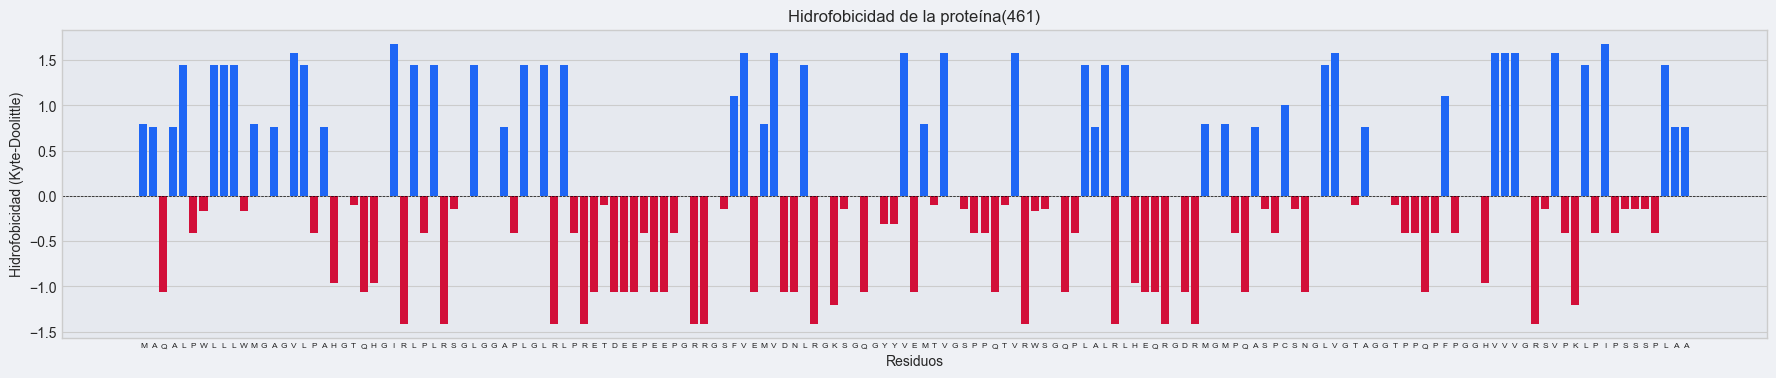

In [86]:
import matplotlib.pyplot as plt

# valores obtenidos de la tabla de hidrofobicidad de Kyte-Doolittle en:
# https://www.frontiersin.org/journals/molecular-biosciences/articles/10.3389/fmolb.2022.960194/full
KY_DO = {
    "A":  0.76, "R": -1.41, "N": -1.06, "D": -1.06, "C":  1.00, 
    "Q": -1.06, "E": -1.06, "G":  0.00, "H": -0.96, "I":  1.68, 
    "L":  1.44, "K": -1.20, "M":  0.79, "F":  1.10, "P": -0.41, 
    "S": -0.14, "T": -0.10, "W": -0.17, "Y": -0.31, "V":  1.58
}

seq = protein_1.sequence
x = range(protein_1.length)
y = [KY_DO[aa] for aa in seq]

fig, ax = plt.subplots(figsize=(22, 4), facecolor="#eff1f5")
colors = ["#1e66f5" if i >= 0 else "#d20f39" for i in y]
ax.bar(x, y, color=colors, linewidth=0.8)


# esta es la linea del eje x
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")

# Cada aminoácido en el eje X
ax.set_xticks(range(protein_1.length))
ax.set_xticklabels(list(seq), fontsize=6)
ax.set_facecolor("#e6e9ef")
ax.grid(False, axis='x')

ax.set_ylabel("Hidrofobicidad (Kyte-Doolittle)")
ax.set_xlabel("Residuos")
ax.set_title(f"Hidrofobicidad de la proteína({protein_1.start})")


plt.show()